In [1]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20

# Initial the exp assay path variable
exp_anno_local = None

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_expAssays.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""exp_assays""","""scaled_fitness""","""#66BB6A""","""aPCA fitness""",1
"""exp_assays""","""DMS""","""#66BB6A""","""DMS""",-1
"""exp_assays""","""DMS_b""","""#66BB6A""","""DMS""",-1
"""exp_assays""","""GCK_activity""","""#66BB6A""","""GCK activity""",-1
"""exp_assays""","""GCK_abundance""","""#81C784""","""GCK abundance""",-1
…,…,…,…,…
"""protein_domains""","""low_complexity_domain""","""#FF9933""","""Low Complexity Domain""",1
"""loftee_protein_domains""","""loftee_disorder""","""#E31A1C""","""Disordered Domain""",1
"""loftee_protein_domains""","""loftee_lip""","""#1E90FF""","""Linear Interacting Peptides""",1


In [3]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000067900""","""lymphocyte_count_int""",0.015659,-0.097882,0.097882,-1.0
"""ENSG00000145386""","""mean_corpuscular_haemoglobin_i…",0.000096,-0.059845,0.059845,-1.0
"""ENSG00000164944""","""trunk_predicted_mass_int""",0.015511,-0.04623,0.04623,-1.0
"""ENSG00000107863""","""trunk_predicted_mass_int""",0.033889,-0.122605,0.122605,-1.0
"""ENSG00000121966""","""eosinophill_percentage_int""",0.000392,-0.075765,0.075765,-1.0
…,…,…,…,…,…
"""ENSG00000142208""","""arm_predicted_mass_right_int""",0.009537,-0.049973,0.049973,-1.0
"""ENSG00000101670""","""cholesterol_int""",0.000099,0.035791,0.035791,1.0
"""ENSG00000017427""","""weight_int""",0.000158,-0.170599,0.170599,-1.0


In [4]:
# # ProteinGym DMS data

# gene_id = "ENSG00000106633" # GCK. Gersing et al. A comprehensive map of human glucokinase variant activity. Genome Biol. 2023;24:97.
# pheno = 'glycated_haemoglobin_hba1c_int'
# rename_mapping = {
#     'HXK4_HUMAN_Gersing_2023_abundance': 'GCK_abundance',
#     'HXK4_HUMAN_Gersing_2022_activity': 'GCK_activity',
# }
# assay2plot = ['GCK_abundance', 'GCK_activity']

# exp_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/experimental_assays"
# exp_anno_filename = "DMS_ProteinGym_substitutions.parquet"

# LOCAL_EXP_DIR = "/home/dnanexus/data_dir/experimental_assays"
# !mkdir -p {LOCAL_EXP_DIR}
# !dx download {exp_anno_path}/{exp_anno_filename} -o {LOCAL_EXP_DIR}

# exp_anno_local = f'{LOCAL_EXP_DIR}/{exp_anno_filename}'

# id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']
# exp_anno_df = (
#     pl.read_parquet(exp_anno_local)
#     .filter(pl.col('region')==gene_id)
#     .drop_nulls(subset=id_cols)
#     .pivot(
#         index=id_cols,
#         on='file_name',
#         values='DMS_score'
#     )
#     .rename(rename_mapping)
# )

# exp_assay_columns = list(set(exp_anno_df.columns) - set(id_cols))
# exp_assay_columns = [col for col in exp_assay_columns if col in assay2plot]

# exp_anno_df = exp_anno_df.select(id_cols + exp_assay_columns)
# exp_anno_df

In [5]:
# Marsh assays

# gene_id = "ENSG00000132170" # PPARG. Majithia et al. Prospective functional classification of all possible missense variants in PPARG. Nat Genet. 2016;48:1570–5.
# pheno = 'hdl_cholesterol_int'
# assay2plot = "DMS"

gene_id = "ENSG00000171862" # PTEN (DMS_highqual_b). Matreyek et al (2018) Multiplex assessment of protein variant abundance by massively parallel sequencing. Nat Genet 50: 874–882
pheno = 'igf1_int'
assay2plot = 'DMS_b'

exp_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/experimental_assays"

exp_anno_filename = "DMS_Marsh_VEP.parquet"
exp_assay_type_column = 'DMS_assay'
exp_assay_score_column = 'DMS_score'

LOCAL_EXP_DIR = "/home/dnanexus/data_dir/experimental_assays"
!mkdir -p {LOCAL_EXP_DIR}
!dx download {exp_anno_path}/{exp_anno_filename} -o {LOCAL_EXP_DIR}

exp_anno_local = f'{LOCAL_EXP_DIR}/{exp_anno_filename}'

id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']
exp_anno_df = (
    pl.read_parquet(exp_anno_local)
    .filter(pl.col('region')==gene_id)
    .drop_nulls(subset=id_cols)
    .pivot(
        index=id_cols,
        on=exp_assay_type_column,
        values=exp_assay_score_column
    )
)

exp_assay_columns = list(set(exp_anno_df.columns) - set(id_cols))
exp_assay_columns = [assay2plot]

exp_anno_df = exp_anno_df.select(id_cols + exp_assay_columns)

exp_anno_df

[===========================================================>] Completed 8,835,874 of 8,835,874 bytes (100%) /home/dnanexus/data_dir/experimental_assays/DMS_Marsh_VEP.parquett


ref_aa,aa_position,alt_aa,region,DMS_b
str,i64,str,str,f64
"""L""",146,"""F""","""ENSG00000171862""",-0.316321
"""E""",150,"""P""","""ENSG00000171862""",0.007277
"""I""",50,"""A""","""ENSG00000171862""",-0.681732
"""V""",85,"""L""","""ENSG00000171862""",-0.700592
"""M""",270,"""K""","""ENSG00000171862""",-0.927264
…,…,…,…,…
"""R""",233,"""D""","""ENSG00000171862""",-1.103084
"""P""",103,"""L""","""ENSG00000171862""",-1.132672
"""C""",136,"""H""","""ENSG00000171862""",-4.19239


In [6]:
# gene_id = "ENSG00000130164" # LDLR. Roth et al. Science 2025
# pheno = 'ldl_direct_int'
# assay2plot = 'LDL_uptake_functional'

# exp_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/experimental_assays"

# exp_anno_filename = "LDLR_Roth_Science_2025.parquet"
# exp_assay_type_column = 'assay'
# exp_assay_score_column = 'score'

# LOCAL_EXP_DIR = "/home/dnanexus/data_dir/experimental_assays"
# !mkdir -p {LOCAL_EXP_DIR}
# !dx download {exp_anno_path}/{exp_anno_filename} -o {LOCAL_EXP_DIR}

# exp_anno_local = f'{LOCAL_EXP_DIR}/{exp_anno_filename}'

# id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']
# exp_anno_df = (
#     pl.read_parquet(exp_anno_local)
#     .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
#     .drop_nulls(subset=id_cols)
#     # .select(id_cols + exp_assay_type_columns + exp_assay_score_columns)
#     .pivot(
#         index=id_cols,
#         on=exp_assay_type_column,
#         values=exp_assay_score_column
#     )
# )

# exp_assay_columns = list(set(exp_anno_df.columns) - set(id_cols))
# exp_assay_columns = ['LDL_uptake_functional', 'LDLR_cell_surface_abundance']

# exp_anno_df = exp_anno_df.select(id_cols + exp_assay_columns)

# exp_anno_df

In [7]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_with_all_old.parquet"
ANNO_FILE = "annotations_with_all_no_dup.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

gene_trait_df = (
    gene_trait_df
    .filter(
        pl.col('region') == gene_id,
        pl.col('phenotype') == pheno,
    )
)

# Join new annotation if specified above
if exp_anno_local is not None:
    anno = (
        anno
        .filter(
            pl.col('amino_acids').is_not_null(),
            pl.col('amino_acids').str.contains("/"),
            ~pl.col('protein_position').str.contains("-")
        )
        .with_columns(
            pl.col("amino_acids").str.split("/").list.get(0).alias("ref_aa"),
            pl.col("amino_acids").str.split("/").list.get(1).alias("alt_aa"),
            pl.col("protein_position").str.split("/").list.get(0).cast(pl.Int64).alias("aa_position")
        )

        .join(
            exp_anno_df.lazy(),
            on=['ref_aa', 'aa_position', 'alt_aa', 'region'],
            how='left'
        )

        # Restrict to variants with experimental assay data
        .drop_nulls(exp_assay_columns)
    )


anno = (
    anno
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        
        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True),
        # (pl.col('consequence_synonymous_variant') == True),

        # Filter for missense variants that we can merge with exp assay data
        # (pl.col('amino_acids').is_not_null()) & (pl.col('amino_acids').str.contains("/")) & (~pl.col('protein_position').str.contains("-")),

        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),
        
        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('mobi_disorder_full') == True),

        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    
)

selected_categories = ['missense', 'conservation'] # missense
# selected_categories = ['protein_domains'] # protein domains
# selected_categories = ['loftee_protein_domains'] # protein domains
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # synonymous
# selected_categories = ['plof', 'missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # CDS

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

selected_annos = list(set(selected_annos).intersection(set(existing_annos))) + exp_assay_columns
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all_no_dup.parquet"
already exists but -f/--overwrite was not set


/tmp/ipykernel_309285/3581819911.py:87: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_309285/3581819911.py:97: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


revel_score,priphylop,region,am_pathogenicity,gpn_score,mamphylop,DMS_b,id,verphylop,esmscoremissense,bayes_del,cpt1_llr,clinpred_score,polyphen
f32,f32,str,f32,f32,f32,f64,str,f32,f32,f32,f32,f32,f32
0.591,0.595,"""ENSG00000171862""",0.8154,-8.38,4.361,-1.016107,"""chr10:87961096:G:A""",7.446,-10.61,0.054872,0.441054,0.87827,0.231
0.374,0.475,"""ENSG00000171862""",0.1074,-8.44,3.329,-0.002441,"""chr10:87965375:A:G""",8.29,-7.0,-0.17634,0.158872,0.486097,0.178
0.583,0.418,"""ENSG00000171862""",0.9861,-10.47,2.825,-0.215854,"""chr10:87952200:C:A""",7.112,-11.432,0.303766,0.482211,0.846744,0.18
0.319,0.595,"""ENSG00000171862""",0.0867,-8.66,2.604,0.053321,"""chr10:87965334:G:C""",5.311,-4.804,-0.114677,0.130939,0.371742,0.007
0.648,0.418,"""ENSG00000171862""",0.9305,-8.61,2.871,0.106335,"""chr10:87957918:C:T""",4.196,-11.465,0.073672,0.462552,0.9906,0.97
…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.26,0.475,"""ENSG00000171862""",0.6924,-10.95,3.274,-0.223442,"""chr10:87952259:A:G""",8.212,-8.643,-0.157976,0.31156,0.867074,0.005
0.968,0.475,"""ENSG00000171862""",0.9967,-10.82,3.329,-2.268812,"""chr10:87933223:A:G""",8.264,-12.262,0.427969,0.714843,0.999594,0.999
0.471,0.475,"""ENSG00000171862""",0.0731,-11.46,3.329,0.175907,"""chr10:87958000:A:C""",8.264,-7.51,0.105041,0.183476,0.974971,0.003


In [8]:
melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
        
    # Keep variants that don't have fillna annotation
    # .join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='semi'
    # )
    
    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr10:87961096:G:A""","""ENSG00000171862""","""revel_score""",0.591
"""chr10:87965375:A:G""","""ENSG00000171862""","""revel_score""",0.374
"""chr10:87952200:C:A""","""ENSG00000171862""","""revel_score""",0.583
"""chr10:87965334:G:C""","""ENSG00000171862""","""revel_score""",0.319
"""chr10:87957918:C:T""","""ENSG00000171862""","""revel_score""",0.648
…,…,…,…
"""chr10:87933150:A:G""","""ENSG00000171862""","""polyphen""",0.996
"""chr10:87933223:A:G""","""ENSG00000171862""","""DMS_b""",-2.268812
"""chr10:87958000:A:C""","""ENSG00000171862""","""DMS_b""",0.175907


In [9]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


In [10]:
from scipy.stats import spearmanr, norm

ci_alpha = 0.05
z_crit = norm.ppf(1 - ci_alpha / 2)  # 1.96 for 95% CI

# --- 1. Collect the pre-correlation data ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())

pre_corr_data = (
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_na' in c]),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df["region", "phenotype"].lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .filter(pl.col('annotation') != 'loftee_hc')
    .collect(engine='streaming')
)

# --- 2. Spearman correlation with Fisher Z-transformation CI ---
results = []

for (region, phenotype, annotation), group in pre_corr_data.group_by(['region', 'phenotype', 'annotation']):
    scores = group['annotation_score'].to_numpy().astype(np.float64)
    pheno_vals = group['mean_pheno_value'].to_numpy().astype(np.float64)
    
    # Drop NaN pairs
    mask = ~(np.isnan(scores) | np.isnan(pheno_vals))
    scores, pheno_vals = scores[mask], pheno_vals[mask]
    n = len(scores)
    
    if n < 3 or len(np.unique(scores)) < 2 or len(np.unique(pheno_vals)) < 2:
        continue
    
    # Original correlation
    orig_corr, _ = spearmanr(scores, pheno_vals)
    
    # Fisher Z-transformation for CI
    z = np.arctanh(orig_corr)
    se_z = 1 / np.sqrt(n - 3)
    z_ci_low = z - z_crit * se_z
    z_ci_high = z + z_crit * se_z
    ci_low = np.tanh(z_ci_low)
    ci_high = np.tanh(z_ci_high)
    
    results.append({
        'region': region, 
        'phenotype': phenotype, 
        'annotation': annotation,
        'n_variants': n, 
        'correlation': orig_corr, 
        'ci_low': ci_low, 
        'ci_high': ci_high,
    })

final_lazy_plan = pl.DataFrame(results)

# --- 3. Join with beta directions and annotation directions ---
correlation_df = (
    final_lazy_plan
    .join(anno_config_df.drop('category').unique(), on='annotation')
    .join(gene_trait_df, on=['region', 'phenotype'])
    .with_columns(
        corr_beta = pl.col('correlation') * pl.col('loftee_corr_dir') * pl.col('annotation_dir'),
        ci_low_beta = pl.col('ci_low') * pl.col('loftee_corr_dir') * pl.col('annotation_dir'),
        ci_high_beta = pl.col('ci_high') * pl.col('loftee_corr_dir') * pl.col('annotation_dir'),
    )
    # When direction flips the sign, ci_low/ci_high swap — fix ordering
    .with_columns(
        ci_low_beta_final = pl.min_horizontal('ci_low_beta', 'ci_high_beta'),
        ci_high_beta_final = pl.max_horizontal('ci_low_beta', 'ci_high_beta'),
    )
    .drop(['ci_low_beta', 'ci_high_beta'])
    .rename({'ci_low_beta_final': 'ci_low_beta', 'ci_high_beta_final': 'ci_high_beta'})
)

print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (12, 17)


region,phenotype,annotation,n_variants,correlation,ci_low,ci_high,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,ci_low_beta,ci_high_beta
str,str,str,i64,f64,f64,f64,str,str,i8,f64,f64,f64,f64,f64,f64,f64
"""ENSG00000171862""","""igf1_int""","""esmscoremissense""",111,0.342801,0.167084,0.497411,"""#CD853F""","""ESM1v""",-1,0.032435,-0.108391,0.108391,-1.0,0.342801,0.167084,0.497411
"""ENSG00000171862""","""igf1_int""","""verphylop""",111,-0.111129,-0.291484,0.076856,"""#08306B""","""Vertebrate PhyloP""",1,0.032435,-0.108391,0.108391,-1.0,0.111129,-0.076856,0.291484
"""ENSG00000171862""","""igf1_int""","""bayes_del""",111,-0.398192,-0.544195,-0.22878,"""#FFBF00""","""BayesDel""",1,0.032435,-0.108391,0.108391,-1.0,0.398192,0.22878,0.544195
"""ENSG00000171862""","""igf1_int""","""polyphen""",111,-0.174306,-0.349349,0.012493,"""#FF90AA""","""PolyPhen2""",1,0.032435,-0.108391,0.108391,-1.0,0.174306,-0.012493,0.349349
"""ENSG00000171862""","""igf1_int""","""gpn_score""",111,0.259065,0.076359,0.424938,"""#807DBA""","""GPN-MSA""",-1,0.032435,-0.108391,0.108391,-1.0,0.259065,0.076359,0.424938
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000171862""","""igf1_int""","""clinpred_score""",111,-0.282582,-0.445509,-0.101537,"""#FFDC80""","""ClinPred""",1,0.032435,-0.108391,0.108391,-1.0,0.282582,0.101537,0.445509
"""ENSG00000171862""","""igf1_int""","""revel_score""",111,-0.375249,-0.524927,-0.203059,"""#FF7000""","""REVEL""",1,0.032435,-0.108391,0.108391,-1.0,0.375249,0.203059,0.524927
"""ENSG00000171862""","""igf1_int""","""priphylop""",111,-0.042998,-0.227567,0.144554,"""#3F007D""","""Primate PhyloP""",1,0.032435,-0.108391,0.108391,-1.0,0.042998,-0.144554,0.227567


In [11]:

consistent_gt = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'phenotype'])
    .agg(n_annotations = pl.len())
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'phenotype'], how='inner')
filt_corr_df

region,phenotype,annotation,n_variants,correlation,ci_low,ci_high,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,ci_low_beta,ci_high_beta,n_annotations
str,str,str,i64,f64,f64,f64,str,str,i8,f64,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000171862""","""igf1_int""","""esmscoremissense""",111,0.342801,0.167084,0.497411,"""#CD853F""","""ESM1v""",-1,0.032435,-0.108391,0.108391,-1.0,0.342801,0.167084,0.497411,12
"""ENSG00000171862""","""igf1_int""","""verphylop""",111,-0.111129,-0.291484,0.076856,"""#08306B""","""Vertebrate PhyloP""",1,0.032435,-0.108391,0.108391,-1.0,0.111129,-0.076856,0.291484,12
"""ENSG00000171862""","""igf1_int""","""bayes_del""",111,-0.398192,-0.544195,-0.22878,"""#FFBF00""","""BayesDel""",1,0.032435,-0.108391,0.108391,-1.0,0.398192,0.22878,0.544195,12
"""ENSG00000171862""","""igf1_int""","""polyphen""",111,-0.174306,-0.349349,0.012493,"""#FF90AA""","""PolyPhen2""",1,0.032435,-0.108391,0.108391,-1.0,0.174306,-0.012493,0.349349,12
"""ENSG00000171862""","""igf1_int""","""gpn_score""",111,0.259065,0.076359,0.424938,"""#807DBA""","""GPN-MSA""",-1,0.032435,-0.108391,0.108391,-1.0,0.259065,0.076359,0.424938,12
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000171862""","""igf1_int""","""clinpred_score""",111,-0.282582,-0.445509,-0.101537,"""#FFDC80""","""ClinPred""",1,0.032435,-0.108391,0.108391,-1.0,0.282582,0.101537,0.445509,12
"""ENSG00000171862""","""igf1_int""","""revel_score""",111,-0.375249,-0.524927,-0.203059,"""#FF7000""","""REVEL""",1,0.032435,-0.108391,0.108391,-1.0,0.375249,0.203059,0.524927,12
"""ENSG00000171862""","""igf1_int""","""priphylop""",111,-0.042998,-0.227567,0.144554,"""#3F007D""","""Primate PhyloP""",1,0.032435,-0.108391,0.108391,-1.0,0.042998,-0.144554,0.227567,12


In [12]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


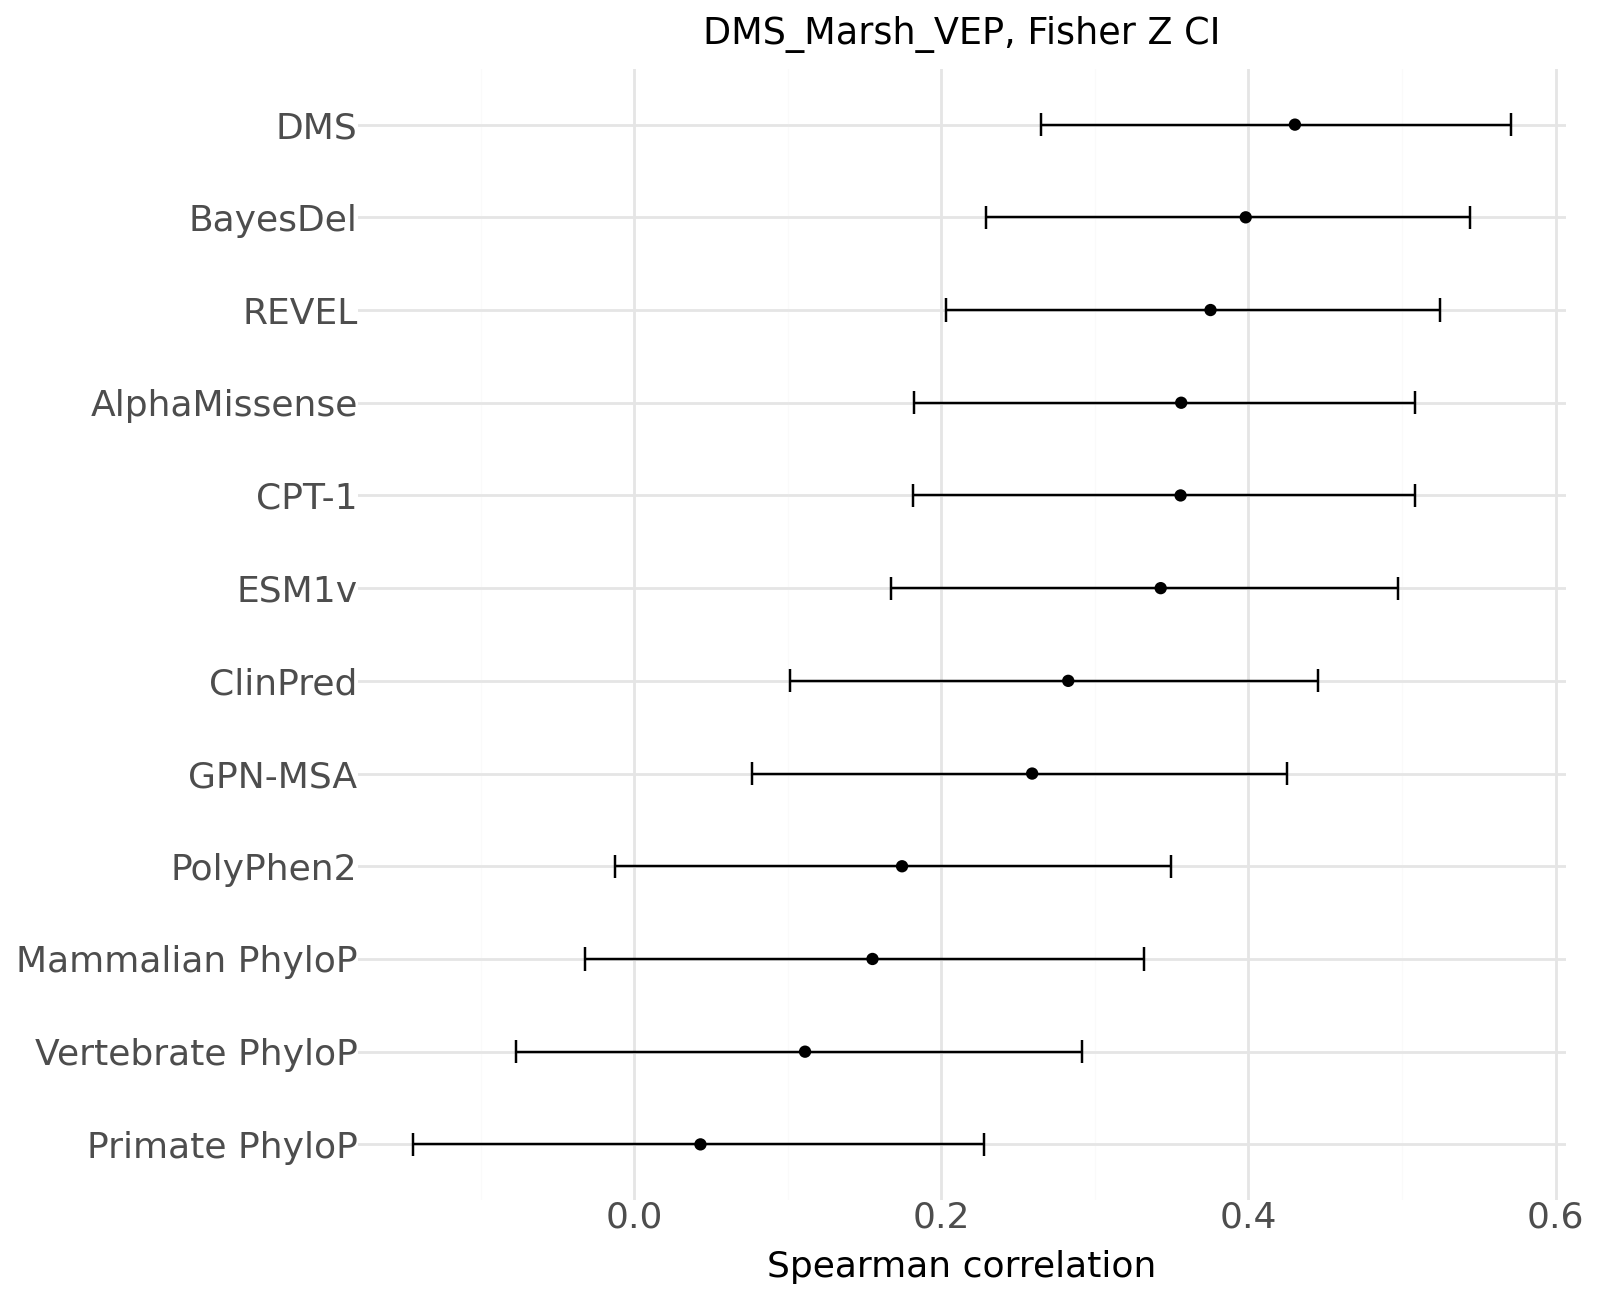

In [13]:
plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Calculate medians and join back
corr_pl = (
    filt_corr_df
    .drop_nans()
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)

# 2. Determine the categorical order for the labels
ordered_labels = (
    corr_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

# 3. Apply the ordering using pl.Enum
corr_pl = corr_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))

# 4. Create the color dictionary (Polars style)
color_dict = dict(corr_pl.select("annotation", "color").unique().iter_rows())

# Plot
(
    ggplot(corr_pl, aes(x="label", y=plotting_col))
    # + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_point(size=1.5)
    + geom_errorbar(aes(ymin="ci_low_beta", ymax="ci_high_beta"), width=0.25)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{exp_anno_filename.replace('.parquet', '')}, Fisher Z CI"
    )
    + coord_flip()
    + theme(
        figure_size=(8, corr_pl['annotation'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

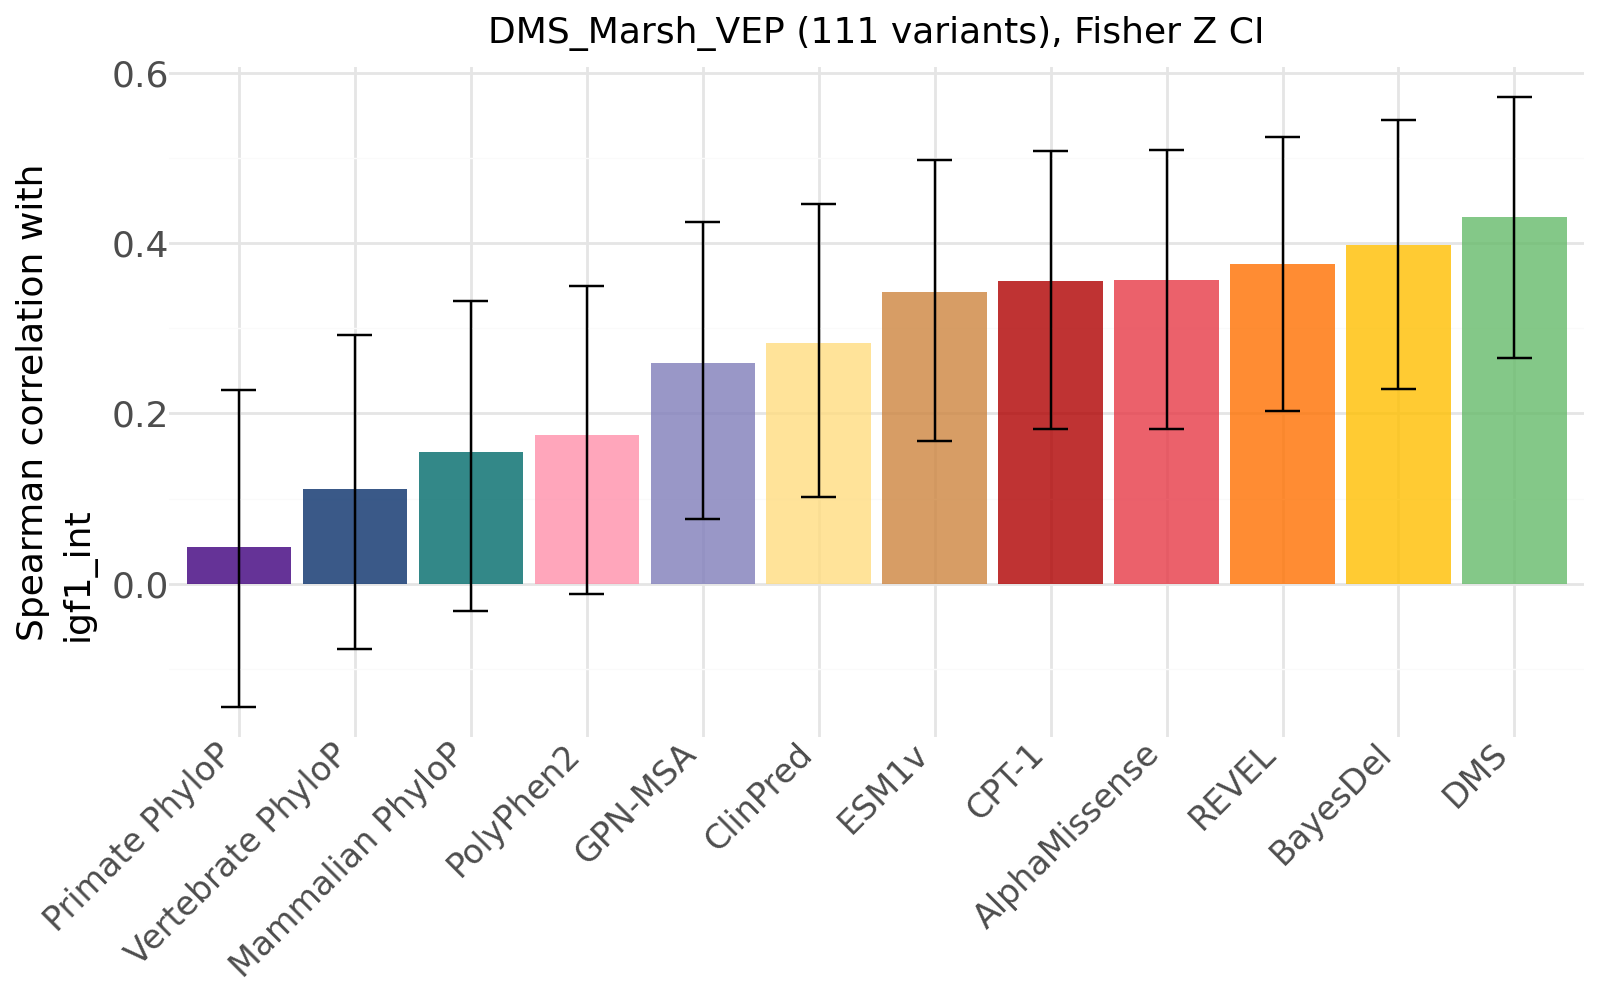

In [14]:
# Vertical bar plot with colored bars and CI error bars
color_dict_label = dict(corr_pl.select("label", "color").unique().iter_rows())

(
    ggplot(corr_pl, aes(x="label", y=plotting_col, fill="label"))
    + geom_col(alpha=0.8)
    + geom_errorbar(aes(ymin="ci_low_beta", ymax="ci_high_beta"), width=0.3, size=0.5)
    + scale_fill_manual(values=color_dict_label)
    + labs(
        x="",
        y=f"Spearman correlation with\n{pheno}",
        title=f"{exp_anno_filename.replace('.parquet', '')} ({corr_pl['n_variants'].unique().item()} variants), Fisher Z CI"
    )
    + theme_minimal()
    + theme(
        figure_size=(corr_pl['annotation'].n_unique()/2 + 2, 5),
        legend_position="none",
        axis_text_x=element_text(size=12, rotation=45, ha='right'),
        axis_text_y=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [15]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_309285/1012804157.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
